# LAB 6 - Visualisasi Data dengan Seaborn

## Praktikum Analitik dan Visualisasi Data

Notebook ini membahas visualisasi statistik menggunakan **Seaborn** pada dataset **Olist E-Commerce**.  
Fokus praktikum meliputi:
- Distribution plots
- Boxplot
- Violinplot
- Countplot
- Barplot
- Heatmap dan correlation matrix
- Interpretasi statistik dari visualisasi

---
### Petunjuk
1. Pastikan dataset berada pada folder `../dataset/`
2. Jalankan cell secara berurutan
3. Setiap visualisasi wajib diikuti interpretasi hasil
4. Pahami perbedaan antara plot distribusi, plot kategorikal, dan plot korelasi


## 1. Tujuan Praktikum

Setelah menyelesaikan praktikum ini, mahasiswa diharapkan mampu:

1. Menggunakan library **Seaborn** untuk membuat visualisasi statistik pada dataset.
2. Memilih jenis plot yang sesuai berdasarkan karakteristik data, baik numerik maupun kategorikal.
3. Membuat dan menginterpretasikan:
   - **boxplot** untuk mendeteksi outlier dan melihat sebaran data
   - **violinplot** untuk memahami bentuk distribusi data
   - **distribution plot** seperti histogram dan kdeplot untuk menganalisis distribusi variabel numerik
   - **countplot** untuk menghitung frekuensi kategori
   - **barplot** untuk membandingkan nilai agregat antar kategori
   - **heatmap** untuk menganalisis korelasi antar variabel numerik
4. Mengidentifikasi pola distribusi data seperti:
   - simetris
   - skewed
   - multimodal
5. Menghubungkan hasil visualisasi statistik dengan konteks analisis data dan pengambilan keputusan.


## 2. Import Library

Pada tahap ini, kita mengimpor library yang dibutuhkan untuk pengolahan data dan visualisasi statistik.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 3. Load Dataset

Dataset yang digunakan:
- `olist_orders_dataset.csv`
- `olist_order_items_dataset.csv`
- `olist_products_dataset.csv`

> Pastikan file berada di folder `../dataset/`


In [2]:
orders_path = '../dataset/olist_orders_dataset.csv'
items_path = '../dataset/olist_order_items_dataset.csv'
products_path = '../dataset/olist_products_dataset.csv'

df_orders = pd.read_csv(orders_path)
df_items = pd.read_csv(items_path)
df_products = pd.read_csv(products_path)

print("df_orders:", df_orders.shape)
print("df_items:", df_items.shape)
print("df_products:", df_products.shape)

df_orders: (99441, 8)
df_items: (112650, 7)
df_products: (32951, 9)


## 4. Preview Data

Lakukan pengecekan awal terhadap struktur data.


In [3]:
display(df_orders.head())
display(df_items.head())
display(df_products.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## 5. Data Preparation

Pada tahap ini dilakukan:
1. Konversi kolom tanggal menjadi format datetime
2. Membuat kolom bulan transaksi
3. Menggabungkan dataset agar analisis lebih bermakna


In [4]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

df = df_orders.merge(df_items, on='order_id', how='inner')
df = df.merge(df_products, on='product_id', how='left')

print("Shape data gabungan:", df.shape)
display(df.head())

Shape data gabungan: (112650, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


## 6. Cek Missing Values

Pengecekan missing values penting agar visualisasi statistik tidak bias atau gagal dijalankan.


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0].head(20)

order_delivered_customer_date    2454
product_photos_qty               1603
product_description_lenght       1603
product_name_lenght              1603
product_category_name            1603
order_delivered_carrier_date     1194
product_width_cm                   18
product_height_cm                  18
product_length_cm                  18
product_weight_g                   18
order_approved_at                  15
dtype: int64

## 7. Distribution Plot: Histogram dan KDE

Visualisasi ini digunakan untuk memahami distribusi variabel numerik, misalnya `price`.
Histogram menunjukkan frekuensi data, sedangkan KDE menunjukkan bentuk kurva distribusi yang lebih halus.


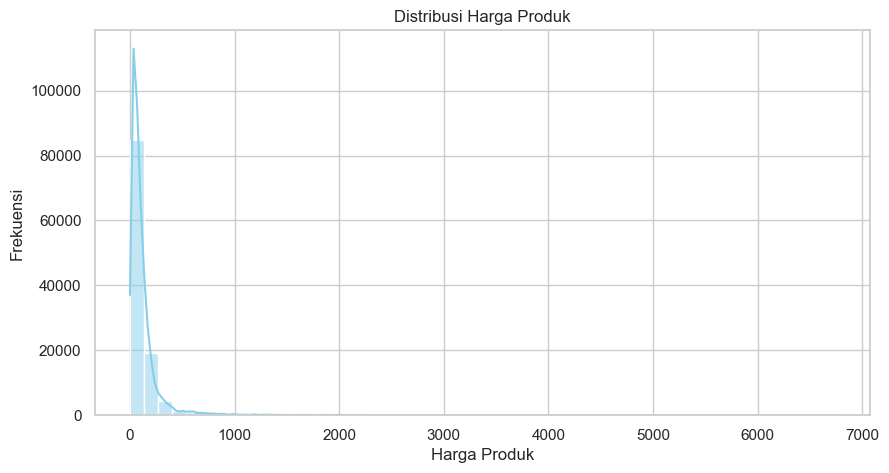

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='price', bins=50, kde=True, color='skyblue')

plt.title('Distribusi Harga Produk')
plt.xlabel('Harga Produk')
plt.ylabel('Frekuensi')
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Apakah distribusi harga cenderung normal atau skewed?
- Apakah mayoritas produk berada pada harga rendah, sedang, atau tinggi?
- Apakah terlihat ekor distribusi yang panjang?


## 8. Boxplot

Boxplot digunakan untuk melihat median, quartile, dan mendeteksi outlier pada data numerik.


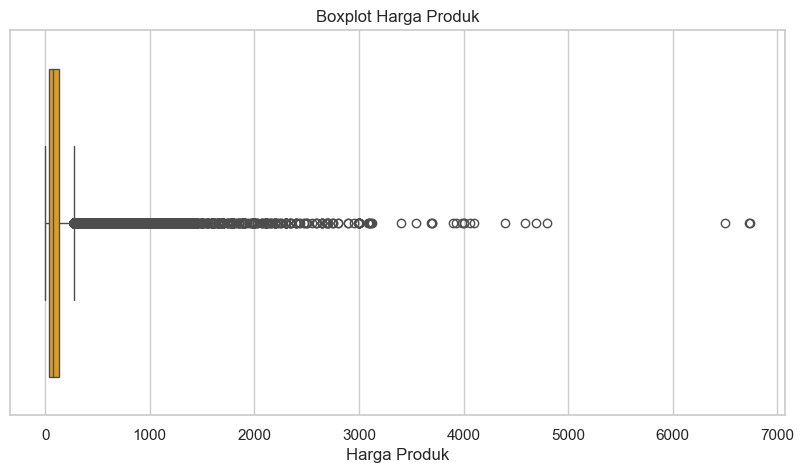

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='price', color='orange')

plt.title('Boxplot Harga Produk')
plt.xlabel('Harga Produk')
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Apakah terdapat banyak outlier?
- Bagaimana posisi median?
- Apakah distribusi terlihat simetris atau condong ke salah satu sisi?


## 9. Violin Plot

Violin plot digunakan untuk melihat bentuk distribusi data secara lebih rinci berdasarkan kategori.
Pada contoh ini digunakan 5 kategori produk teratas.


C:\Users\Asus\AppData\Local\Temp\ipykernel_39112\2767605378.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top, x='product_category_name', y='price', palette='pastel')


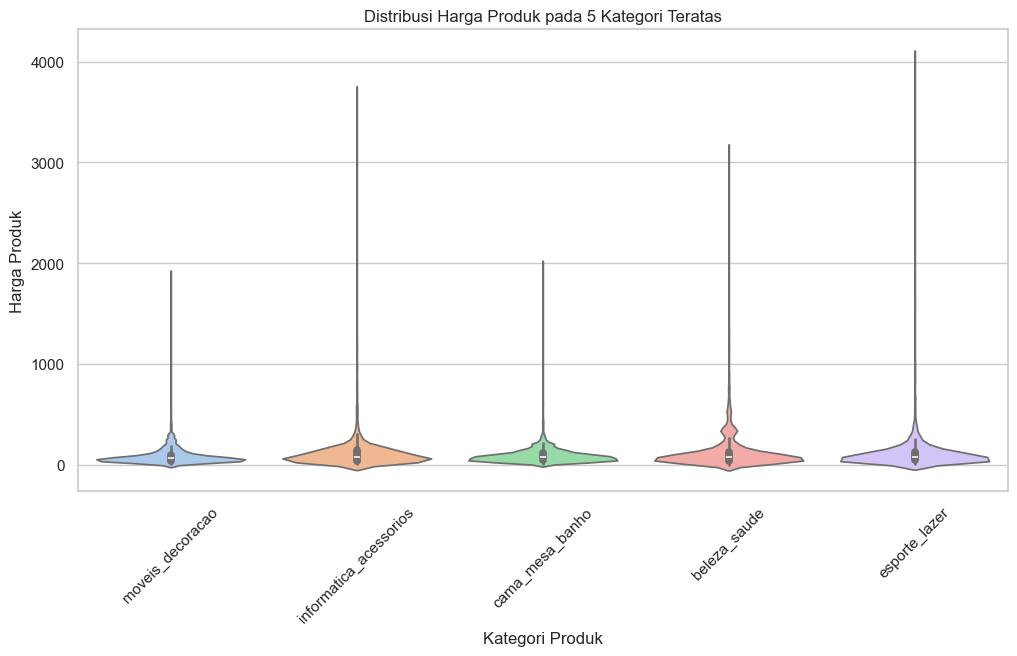

In [8]:
top_categories = df['product_category_name'].value_counts().head(5).index
df_top = df[df['product_category_name'].isin(top_categories)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_top, x='product_category_name', y='price', palette='pastel')

plt.title('Distribusi Harga Produk pada 5 Kategori Teratas')
plt.xlabel('Kategori Produk')
plt.ylabel('Harga Produk')
plt.xticks(rotation=45)
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Kategori mana yang memiliki distribusi harga paling lebar?
- Apakah ada kategori dengan konsentrasi harga tertentu?
- Apakah distribusi antar kategori terlihat seragam?


## 10. Countplot

Countplot digunakan untuk menghitung jumlah observasi pada setiap kategori.


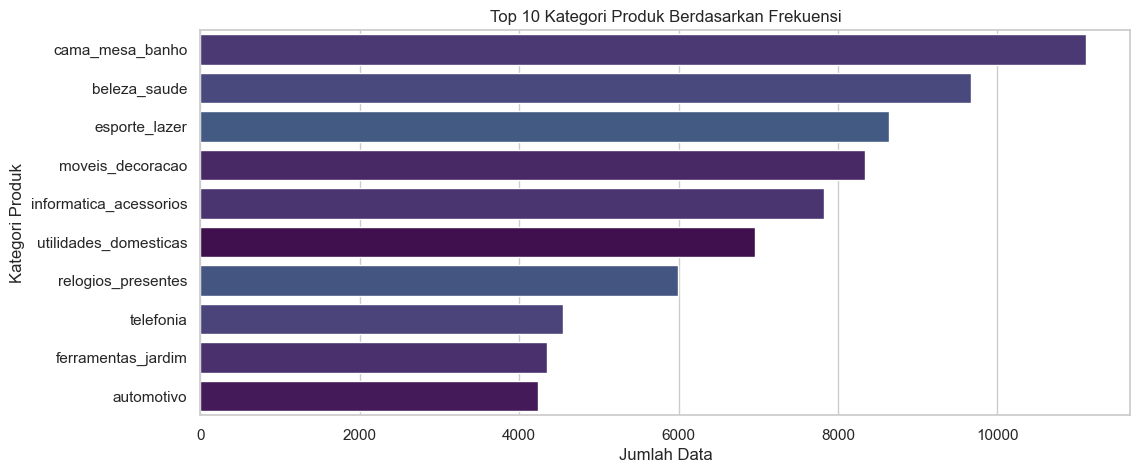

In [9]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    y='product_category_name',
    order=df['product_category_name'].value_counts().head(10).index,
    hue='product_category_name',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Kategori Produk Berdasarkan Frekuensi')
plt.xlabel('Jumlah Data')
plt.ylabel('Kategori Produk')
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Kategori apa yang paling sering muncul?
- Apakah distribusi kategori merata atau terkonsentrasi?
- Apa implikasi dominasi kategori terhadap analisis bisnis?


## 11. Barplot

Barplot digunakan untuk menampilkan nilai agregat (default: mean) dari variabel numerik berdasarkan kategori.
Contoh berikut menampilkan rata-rata harga per kategori produk.


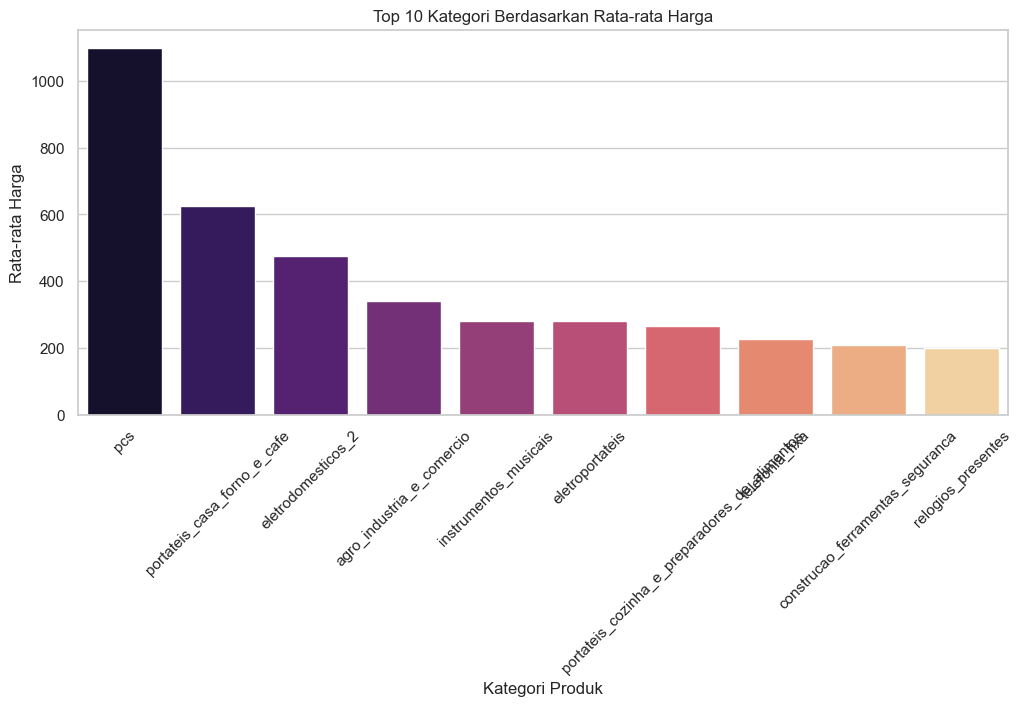

In [10]:
avg_price_category = (
    df.groupby('product_category_name', as_index=False)['price']
    .mean()
    .sort_values(by='price', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=avg_price_category, x='product_category_name', y='price', hue='product_category_name', palette='magma', legend=False)

plt.title('Top 10 Kategori Berdasarkan Rata-rata Harga')
plt.xlabel('Kategori Produk')
plt.ylabel('Rata-rata Harga')
plt.xticks(rotation=45)
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Kategori mana yang memiliki rata-rata harga tertinggi?
- Apakah kategori yang sering muncul juga kategori yang mahal?
- Apa perbedaan insight antara countplot dan barplot?


## 12. Heatmap dan Correlation Matrix

Heatmap digunakan untuk melihat hubungan antar variabel numerik melalui korelasi.


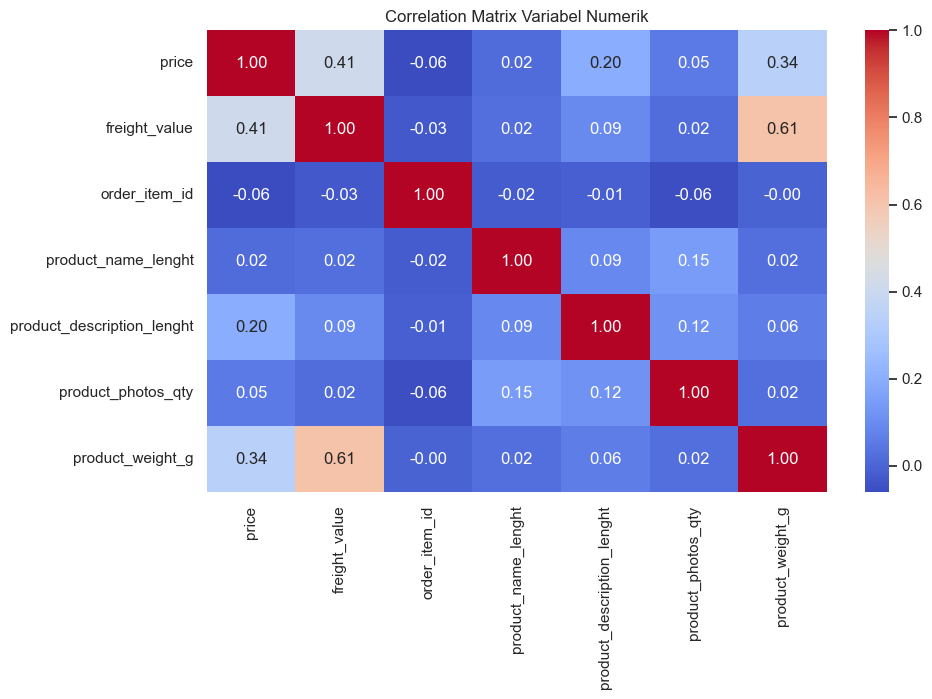

In [11]:
numeric_cols = [
    'price', 'freight_value', 'order_item_id',
    'product_name_lenght', 'product_description_lenght',
    'product_photos_qty', 'product_weight_g'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix Variabel Numerik')
plt.show()

### Interpretasi
Tuliskan interpretasi Anda pada bagian ini:

- Variabel mana yang memiliki korelasi paling kuat?
- Apakah korelasi tersebut positif atau negatif?
- Variabel mana yang hampir tidak berkorelasi?
- Ingat: korelasi tidak selalu berarti sebab-akibat.


## 13. Ringkasan Pemilihan Plot Berdasarkan Tipe Data

Gunakan panduan berikut:

- **Histogram / KDE** → distribusi data numerik
- **Boxplot / Violinplot** → sebaran, median, outlier, density
- **Countplot** → jumlah data kategori
- **Barplot** → rata-rata nilai numerik per kategori
- **Heatmap** → korelasi antar variabel numerik


## 14. Analisis dan Pembahasan

Pada setiap visualisasi, mahasiswa wajib menuliskan:
- **Observasi** → apa yang terlihat
- **Analisis** → apa artinya
- **Insight** → apa implikasinya

Contoh pertanyaan analisis:
- Apakah distribusi harga produk skewed?
- Apakah ada kategori dengan outlier ekstrem?
- Apakah ada korelasi antara harga dan berat produk?
- Apakah kategori yang sering muncul juga memiliki harga tinggi?


## 15. Latihan Mandiri

Kerjakan latihan berikut menggunakan dataset yang sama:

1. Buat **histplot + kde** untuk `freight_value`
2. Buat **boxplot** untuk `freight_value`
3. Buat **violinplot** harga produk berdasarkan 5 kategori teratas
4. Buat **countplot** untuk status order (`order_status`)
5. Buat **barplot** rata-rata `freight_value` per kategori produk
6. Buat **heatmap** untuk variabel numerik lain yang relevan
7. Jelaskan perbedaan insight dari:
   - countplot vs barplot
   - boxplot vs violinplot


## 16. Kesimpulan

Tuliskan kesimpulan praktikum:
- Apa yang dipelajari?
- Plot Seaborn apa yang paling membantu memahami data?
- Insight statistik apa yang paling penting?
